Scanning files to lock global color limits...
Saving animation to lbm_results.gif...
Processing frame 1/31: output-0.txt
Processing frame 1/31: output-0.txt
Processing frame 2/31: output-25.txt
Processing frame 3/31: output-50.txt
Processing frame 4/31: output-75.txt
Processing frame 5/31: output-100.txt
Processing frame 6/31: output-125.txt
Processing frame 7/31: output-150.txt
Processing frame 8/31: output-175.txt
Processing frame 9/31: output-200.txt
Processing frame 10/31: output-225.txt
Processing frame 11/31: output-250.txt
Processing frame 12/31: output-275.txt
Processing frame 13/31: output-300.txt
Processing frame 14/31: output-325.txt
Processing frame 15/31: output-350.txt
Processing frame 16/31: output-375.txt
Processing frame 17/31: output-400.txt
Processing frame 18/31: output-425.txt
Processing frame 19/31: output-450.txt
Processing frame 20/31: output-475.txt
Processing frame 21/31: output-500.txt
Processing frame 22/31: output-525.txt
Processing frame 23/31: output-550.

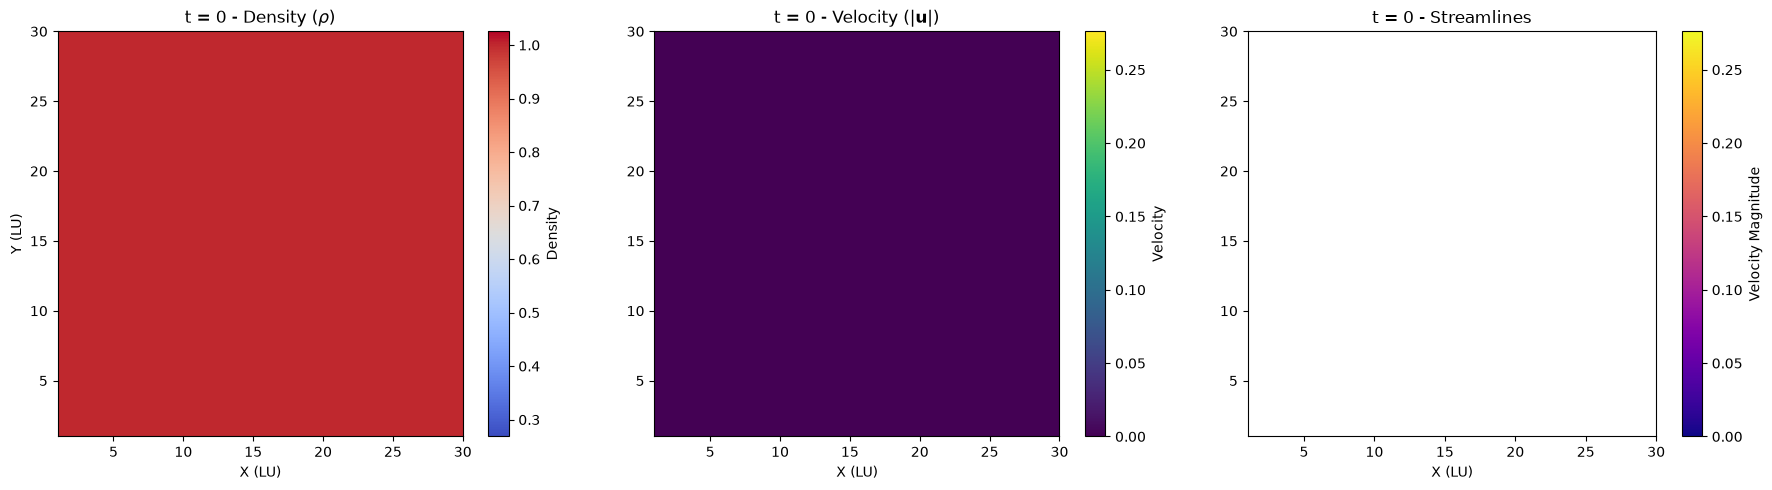

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

def load_lbm_data_from_txt(filename, sigma=0.5):
    """Loads LBM data and applies Gaussian smoothing."""
    try:
        data = np.loadtxt(filename, delimiter=',')
    except Exception as e:
        print(f"Error reading {filename}. Details: {e}")
        return None

    x_1d, y_1d = data[:, 0], data[:, 1]
    rho_1d = data[:, 2]
    ux_1d, uy_1d = data[:, 3], data[:, 4]

    x_unique, y_unique = np.unique(x_1d), np.unique(y_1d)
    nx, ny = len(x_unique), len(y_unique)
    dx = x_unique[1] - x_unique[0] if nx > 1 else 1.0
    dy = y_unique[1] - y_unique[0] if ny > 1 else 1.0

    X, Y = np.meshgrid(x_unique, y_unique)
    U, V, Rho = np.zeros((ny, nx)), np.zeros((ny, nx)), np.zeros((ny, nx))

    col_indices = np.round((x_1d - x_unique[0]) / dx).astype(int)
    row_indices = np.round((y_1d - y_unique[0]) / dy).astype(int)

    U[row_indices, col_indices] = ux_1d
    V[row_indices, col_indices] = uy_1d
    Rho[row_indices, col_indices] = rho_1d

    if sigma > 0:
        Rho = gaussian_filter(Rho, sigma=sigma)
        U = gaussian_filter(U, sigma=sigma)
        V = gaussian_filter(V, sigma=sigma)

    vel_mag = np.sqrt(U**2 + V**2)
    
    # Store grid extents for imshow
    extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]
    
    return X, Y, U, V, Rho, vel_mag, extent

def get_global_limits(filenames, percentile_clip=2):
    """Scans all time steps to establish a locked color scale."""
    print("Scanning files to lock global color limits...")
    all_rho, all_vel = [], []
    for f in filenames:
        result = load_lbm_data_from_txt(f, sigma=0)
        if result is not None:
            _, _, _, _, Rho, vel_mag, _ = result
            all_rho.append(Rho)
            all_vel.append(vel_mag)
            
    rho_arr = np.concatenate([r.flatten() for r in all_rho])
    vel_arr = np.concatenate([v.flatten() for v in all_vel])
    
    vmin_rho, vmax_rho = np.percentile(rho_arr, percentile_clip), np.percentile(rho_arr, 100 - percentile_clip)
    vmin_vel, vmax_vel = np.percentile(vel_arr, percentile_clip), np.percentile(vel_arr, 100 - percentile_clip)
    
    return (vmin_rho, vmax_rho), (vmin_vel, vmax_vel)

def animate_lbm_results(filenames, step_labels, output_filename="lbm_simulation.gif"):
    if not filenames:
        print("No files provided.")
        return

    (vmin_rho, vmax_rho), (vmin_vel, vmax_vel) = get_global_limits(filenames)
    norm_rho = mcolors.Normalize(vmin=vmin_rho, vmax=vmax_rho)
    norm_vel = mcolors.Normalize(vmin=vmin_vel, vmax=vmax_vel)
    
    # Setup Figure and Axes
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_rho, ax_vel, ax_stream = axes

    # Load initial frame
    X, Y, U, V, Rho, vel_mag, extent = load_lbm_data_from_txt(filenames[0])
    
    # Plot Initial Data
    im_rho = ax_rho.imshow(Rho, origin='lower', extent=extent, norm=norm_rho, 
                           cmap='coolwarm', interpolation='bilinear')
    im_vel = ax_vel.imshow(vel_mag, origin='lower', extent=extent, norm=norm_vel, 
                           cmap='viridis', interpolation='bilinear')
    
    # Initial streamplot
    ax_stream.streamplot(X, Y, U, V, color=vel_mag, cmap='plasma', norm=norm_vel)

    # Colorbars
    fig.colorbar(im_rho, ax=ax_rho, label="Density")
    fig.colorbar(im_vel, ax=ax_vel, label="Velocity")
    
    # For streamplot, we map the colorbar to a static ScalarMappable 
    # so it survives the ax.clear() call in the update loop
    sm_stream = plt.cm.ScalarMappable(cmap='plasma', norm=norm_vel)
    sm_stream.set_array([])
    fig.colorbar(sm_stream, ax=ax_stream, label="Velocity Magnitude")

    # Titles & Labels
    title_rho = ax_rho.set_title(rf"{step_labels[0]} - Density ($\rho$)")
    title_vel = ax_vel.set_title(rf"{step_labels[0]} - Velocity ($|\mathbf{{u}}|$)")
    ax_stream.set_title(f"{step_labels[0]} - Streamlines")

    for ax in axes:
        ax.set_xlabel("X (LU)")
    ax_rho.set_ylabel("Y (LU)")

    # Apply tight layout EXACTLY ONCE before the animation starts
    fig.tight_layout()

    def update(frame_idx):
        filename = filenames[frame_idx]
        label = step_labels[frame_idx]
        print(f"Processing frame {frame_idx + 1}/{len(filenames)}: {filename}")
        
        result = load_lbm_data_from_txt(filename, sigma=0.5)
        if result is None: return
        _, _, U, V, Rho, vel_mag, _ = result

        # Fast updates for imshow
        im_rho.set_data(Rho)
        im_vel.set_data(vel_mag)

        # Streamplot must be completely redrawn every frame
        ax_stream.clear()
        
        # Redraw streamlines
        # You can add a `density` parameter here (e.g., density=1.5) if you want thicker/more lines
        ax_stream.streamplot(X, Y, U, V, color=vel_mag, cmap='plasma', norm=norm_vel)
        
        # Redraw title and labels for the cleared axis
        ax_stream.set_title(f"{label} - Streamlines")
        ax_stream.set_xlabel("X (LU)")

        # Update static text for the other axes
        title_rho.set_text(rf"{label} - Density ($\rho$)")
        title_vel.set_text(rf"{label} - Velocity ($|\mathbf{{u}}|$)")

    anim = animation.FuncAnimation(fig, update, frames=len(filenames), interval=200)
    
    print(f"Saving animation to {output_filename}...")
    anim.save(output_filename, writer='pillow', fps=5) 
    print("Done!")

if __name__ == "__main__":
    intervals = 30
    interval_length = 25
    data_files = ["output-0.txt"]
    labels = ["t = 0"]
    
    for i in range(1, intervals + 1):
        data_files.append(f"output-{i * interval_length}.txt")
        labels.append(f"t = {i * interval_length}")
    
    animate_lbm_results(data_files, labels, output_filename="lbm_results.gif")

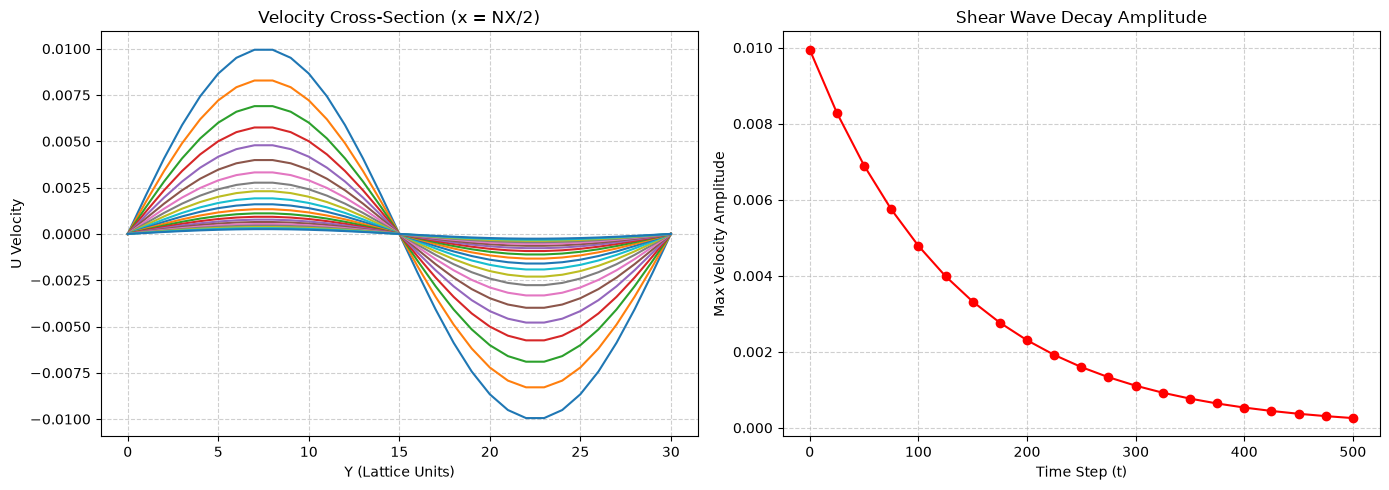

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def generate_lbd2q9_graphs_from_files(data_files, timesteps):
    T = []
    amp = []
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    for file, t in zip(data_files, timesteps):
        try:
            # Read the data: x, y, rho, ux, uy
            data = np.loadtxt(file, delimiter=',')
            
            # Sort data by y then x to ensure consistent reshaping
            # Lexicographical sort: column 1 (y), then column 0 (x)
            data = data[np.lexsort((data[:, 0], data[:, 1]))]
            
            # Determine grid dimensions
            NX = len(np.unique(data[:, 0]))
            NY = len(np.unique(data[:, 1]))
            
            # Extract U-velocity (index 3) and reshape to (NY, NX)
            if data.shape[1] >= 4:
                U = data[:, 3].reshape((NY, NX))
            else:
                raise ValueError(f"File {file} does not have enough columns (expected 5, found {data.shape[1]})")
                
            # Extract velocity cross-section at middle of X
            u_slice = U[:, NX//2]
            u_slice = np.append(u_slice[-1], u_slice)
            ax1.plot(u_slice, label=f't = {t}')
            
            # Extract maximum amplitude
            max_amp = np.max(np.abs(u_slice))
            T.append(t)
            amp.append(max_amp)
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
            
    # Plot formatting
    ax1.set_title("Velocity Cross-Section (x = NX/2)")
    ax1.set_xlabel("Y (Lattice Units)")
    ax1.set_ylabel("U Velocity")
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax2.plot(T, amp, marker='o', linestyle='-', color='red')
    ax2.set_title("Shear Wave Decay Amplitude")
    ax2.set_xlabel("Time Step (t)")
    ax2.set_ylabel("Max Velocity Amplitude")
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    interval = 20
    interval_length = 25
    data_files = ["output-0-shear-wave-1k.txt"]
    timesteps = [0]
    for i in range (1, interval+1):
        data_files.append("output-" + str(i * interval_length) + "-shear-wave-1k.txt")
        timesteps.append(i * interval_length)
    generate_lbd2q9_graphs_from_files(data_files, timesteps)

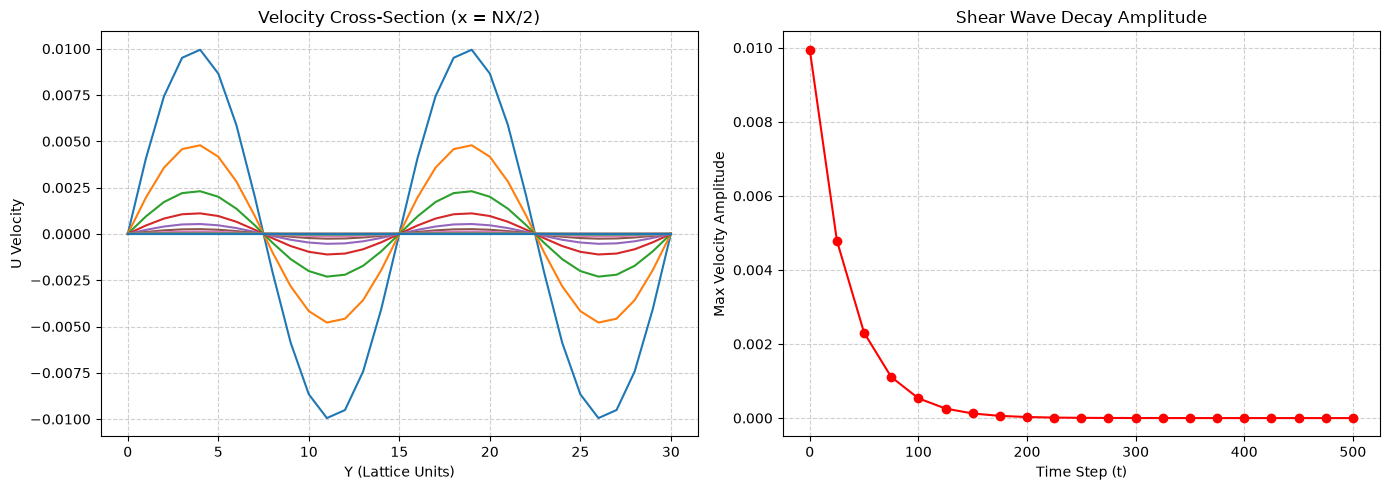

In [20]:
if __name__ == "__main__":
    interval = 20
    interval_length = 25
    data_files = ["output-0-shear-wave-2k.txt"]
    timesteps = [0]
    for i in range (1, interval+1):
        data_files.append("output-" + str(i * interval_length) + "-shear-wave-2k.txt")
        timesteps.append(i * interval_length)
    generate_lbd2q9_graphs_from_files(data_files, timesteps)

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

def generate_2d_velocity_fields(data_files, timesteps, output_dir="plots"):
    """
    Reads multiple LBM simulation files and generates a 2D contour map 
    for each time step, saving them as image files.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    print(f"Generating 2D plots in '{output_dir}'...")
    saved_files = []
    
    for file, t in zip(data_files, timesteps):
        try:
            # np.loadtxt automatically reads all 900 points correctly without skipping lines
            data = np.loadtxt(file, delimiter=',')
            data = data[np.lexsort((data[:, 0], data[:, 1]))]
            
            x_unique = np.unique(data[:, 0])
            y_unique = np.unique(data[:, 1])
            NX = len(x_unique)
            NY = len(y_unique)
            
            # Extract velocities (columns 3 and 4)
            if data.shape[1] >= 5:
                U = data[:, 3].reshape((NY, NX))
                V = data[:, 4].reshape((NY, NX))
                
                # Flip the arrays vertically to invert the momentum injection site
                U = np.flipud(U)
                V = np.flipud(V)
            else:
                raise ValueError(f"File {file} does not have enough columns")
                
            X, Y = np.meshgrid(x_unique, y_unique)
            fig, ax = plt.subplots(figsize=(10, 5))
            
            # Lock the color scale with vmin and vmax to stop animation flickering
            contour = ax.contourf(X, Y, U, levels=50, cmap='viridis', vmin=0.0, vmax=0.1)
            
            cbar = fig.colorbar(contour, ax=ax)
            cbar.set_label('U Velocity (Lattice Units)', rotation=270, labelpad=15)
            
            try:
                # --- REPLACE THE STREAMPLOT BLOCK WITH THIS ---
            
                # Use a step size to prevent the 30x30 grid from becoming a cluttered mess of arrows
                step = 2
                
                # Quiver automatically scales the arrow length to the vector magnitude (U, V)
                ax.quiver(X[::step, ::step], Y[::step, ::step], 
                          U[::step, ::step], V[::step, ::step], 
                          color='white', 
                          scale=1.5,        # Adjust this: smaller number = longer arrows
                          width=0.003,      # Width of the arrow shaft
                          headwidth=5,      # Size of the arrow head
                          pivot='mid')      # Centers the arrow on the coordinate point
                
                # ----------------------------------------------
            except ValueError:
                pass 
            
            ax.axhline(y_unique[-1], color='red', linewidth=3, linestyle='-', label='Moving Wall')
            ax.axhline(y_unique[0], color='black', linewidth=3, linestyle='-', label='Stationary Wall')
            
            ax.set_title(f"2D Velocity Field - Couette Flow (t = {t})")
            ax.set_xlabel("X Position (Lattice Units)")
            ax.set_ylabel("Y Position (Lattice Units)")
            ax.legend(loc='upper right', bbox_to_anchor=(1, 1.15), ncol=2)
            
            filename = os.path.join(output_dir, f"frame_{t:05d}.png")
            
            # Using bbox_inches='tight' locks the layout so labels do not go off screen
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            plt.close(fig)
            
            saved_files.append(filename)
            #print(f"Saved: {filename}")
            
        except Exception as e:
            print(f"Error processing {file} at t={t}: {e}")
            
    return saved_files

def create_gif(image_files, output_filename="couette_flow.gif", duration_ms=100):
    """
    Stitches a list of image files into an animated GIF.
    """
    if not image_files:
        print("No images to create GIF.")
        return

    print(f"Stitching {len(image_files)} frames into {output_filename}...")
    
    # Open all images using Pillow
    frames = [Image.open(image) for image in image_files]
    
    # Save the frames as an animated GIF
    frames[0].save(
        output_filename,
        format='GIF',
        append_images=frames[1:],
        save_all=True,
        duration=duration_ms, # milliseconds per frame
        loop=0 # 0 means loop infinitely
    )
    print(f"GIF saved successfully as {output_filename}")

if __name__ == "__main__":
    interval = 100
    interval_length = 25
    
    data_files = ["output-0-couette.txt"]
    timesteps = [0]
    
    for i in range(1, interval + 1):
        timestep = i * interval_length
        data_files.append(f"output-{timestep}-couette.txt")
        timesteps.append(timestep)
        
    # 1. Generate the individual frames
    generated_images = generate_2d_velocity_fields(data_files, timesteps, output_dir="plots")
    
    # 2. Compile them into a GIF (100ms per frame = 10 frames per second)
    create_gif(generated_images, output_filename="couette_flow.gif", duration_ms=100)

Generating 2D plots in 'plots'...
Stitching 101 frames into couette_flow.gif...
GIF saved successfully as couette_flow.gif


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

def generate_2d_velocity_fields(data_files, timesteps, output_dir="plots"):
    """
    Reads multiple LBM simulation files and generates a 2D contour map 
    for each time step, saving them as image files.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    print(f"Generating 2D plots in '{output_dir}'...")
    saved_files = []
    
    for file, t in zip(data_files, timesteps):
        try:
            data = np.loadtxt(file, delimiter=',')
            data = data[np.lexsort((data[:, 0], data[:, 1]))]
            
            x_unique = np.unique(data[:, 0])
            y_unique = np.unique(data[:, 1])
            NX = len(x_unique)
            NY = len(y_unique)
            
            # Extract velocities (columns 3 and 4)
            if data.shape[1] >= 5:
                U = data[:, 3].reshape((NY, NX))
                V = data[:, 4].reshape((NY, NX))
            else:
                raise ValueError(f"File {file} does not have enough columns")
                
            X, Y = np.meshgrid(x_unique, y_unique)
            fig, ax = plt.subplots(figsize=(10, 5))
            
            contour = ax.contourf(X, Y, U, levels=50, cmap='viridis', vmin=-0.15, vmax=0.15)
            cbar = fig.colorbar(contour, ax=ax)
            cbar.set_label('U Velocity (Lattice Units)', rotation=270, labelpad=15)
            
            try:
                step = 2
                ax.quiver(X[::step, ::step], Y[::step, ::step], 
                          U[::step, ::step], V[::step, ::step], 
                          color='white', scale=1.5, width=0.003, headwidth=5, pivot='mid')
            except ValueError:
                pass 
            
            ax.axhline(y_unique[-1], color='black', linewidth=3, linestyle='-', label='Stationary Wall (Top)')
            ax.axhline(y_unique[0], color='black', linewidth=3, linestyle='-', label='Stationary Wall (Bottom)')
            
            ax.set_title(f"2D Velocity Field - Poiseuille Flow (t = {t})")
            ax.set_xlabel("X Position (Lattice Units)")
            ax.set_ylabel("Y Position (Lattice Units)")
            ax.legend(loc='upper right', bbox_to_anchor=(1, 1.15), ncol=2)
            
            filename = os.path.join(output_dir, f"frame_{t:05d}.png")
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            plt.close(fig)
            saved_files.append(filename)
            
        except Exception as e:
            print(f"Error processing {file} at t={t}: {e}")
            
    return saved_files

def analyze_steady_state(final_file, output_dir="plots"):
    """
    Computes the velocity profile area at the inlet and middle of the channel,
    and plots the density along the centerline for the final timestep.
    """
    print(f"\nAnalyzing steady state properties from '{final_file}'...")
    try:
        data = np.loadtxt(final_file, delimiter=',')
        data = data[np.lexsort((data[:, 0], data[:, 1]))]
        
        x_unique = np.unique(data[:, 0])
        y_unique = np.unique(data[:, 1])
        NX = len(x_unique)
        NY = len(y_unique)
        
        # Assuming standard LBM layout: x, y, rho, u, v
        RHO = data[:, 2].reshape((NY, NX))
        U = data[:, 3].reshape((NY, NX))
        
        # --- Task 2: Compute Area of Velocity Profile ---
        # The area is the integral of U over y: Area = \int U(y) dy
        inlet_idx = 0
        middle_idx = NX // 2
        
        area_inlet = np.trapezoid(U[:, inlet_idx], y_unique)
        area_middle = np.trapezoid(U[:, middle_idx], y_unique)
        
        print("-" * 50)
        print("Velocity Profile Areas (Volumetric Flow Rate):")
        print(f"Area at Inlet (x={x_unique[inlet_idx]}):  {area_inlet:.6f}")
        print(f"Area at Middle (x={x_unique[middle_idx]}): {area_middle:.6f}")
        print("-" * 50)
        
        # --- Task 3: Plot centerline density ---
        centerline_idx = NY // 2
        
        plt.figure(figsize=(10, 5))
        plt.plot(x_unique, RHO[centerline_idx, :], color='red', linewidth=2, label=r'$\rho(x, h/2)$')
        
        plt.title("Density Along the Centerline $\\rho(x, h/2)$")
        plt.xlabel("X Position (Lattice Units)")
        plt.ylabel("Density $\\rho$ (Lattice Units)")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        
        density_filename = os.path.join(output_dir, "centerline_density.png")
        plt.savefig(density_filename, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"Centerline density plot saved successfully as '{density_filename}'\n")
        
    except Exception as e:
        print(f"Error during steady state analysis: {e}")

def create_gif(image_files, output_filename="poiseuille_flow.gif", duration_ms=100):
    """
    Stitches a list of image files into an animated GIF.
    """
    if not image_files:
        print("No images to create GIF.")
        return

    print(f"Stitching {len(image_files)} frames into {output_filename}...")
    frames = [Image.open(image) for image in image_files]
    
    frames[0].save(
        output_filename,
        format='GIF',
        append_images=frames[1:],
        save_all=True,
        duration=duration_ms, 
        loop=0 
    )
    print(f"GIF saved successfully as {output_filename}")

if __name__ == "__main__":
    intervals = 1000
    interval_length = 25
    
    data_files = ["output-0-poiseuille.txt"]
    timesteps = [0]
    
    for i in range(1, intervals + 1):
        timestep = i * interval_length
        data_files.append(f"output-{timestep}-poiseuille.txt")
        timesteps.append(timestep)
        
    # 1. Generate the individual frames
    generated_images = generate_2d_velocity_fields(data_files, timesteps, output_dir="plots")
    
    # 2. Compile them into a GIF
    create_gif(generated_images, output_filename="poiseuille_flow.gif", duration_ms=100)
    
    # 3. Perform the analysis requested on the final time step
    if data_files:
        final_file = data_files[-1]
        analyze_steady_state(final_file, output_dir="plots")

Generating 2D plots in 'plots'...
Stitching 1001 frames into poiseuille_flow.gif...
GIF saved successfully as poiseuille_flow.gif

Analyzing steady state properties from 'output-25000-poiseuille.txt'...
--------------------------------------------------
Velocity Profile Areas (Volumetric Flow Rate):
Area at Inlet (x=1.0):  4.348737
Area at Middle (x=16.0): 4.419993
--------------------------------------------------
Centerline density plot saved successfully as 'plots\centerline_density.png'



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

def generate_2d_velocity_fields(data_files, timesteps, output_dir="plots"):
    """
    Reads multiple LBM simulation files and generates a 2D contour map 
    overlaid with streamlines to show vortices for each time step.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    print(f"Generating 2D plots in '{output_dir}'...")
    saved_files = []
    
    for file, t in zip(data_files, timesteps):
        try:
            data = np.loadtxt(file, delimiter=',')

            max_y = np.max(data[:, 1])
            data[:, 1] = max_y - data[:, 1]
            
            data = data[np.lexsort((data[:, 0], data[:, 1]))]
            
            x_unique = np.unique(data[:, 0])
            y_unique = np.unique(data[:, 1])
            NX = len(x_unique)
            NY = len(y_unique)
            
            # Extract velocities
            if data.shape[1] >= 5:
                U = data[:, 3].reshape((NY, NX))
                V = data[:, 4].reshape((NY, NX))
            else:
                raise ValueError(f"File {file} does not have enough columns")
                
            X, Y = np.meshgrid(x_unique, y_unique)
            fig, ax = plt.subplots(figsize=(8, 6))
            
            # Lock the layout margins so they don't change per frame.
            fig.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.25)
            
            # Plot velocity magnitude for cavity flow as the background
            vel_mag = np.sqrt(U**2 + V**2)
            contour = ax.contourf(X, Y, vel_mag, levels=50, cmap='viridis')
            cbar = fig.colorbar(contour, ax=ax)
            cbar.set_label('Velocity Magnitude', rotation=270, labelpad=15)
            
            # Use streamplot to clearly visualize the vortices
            ax.streamplot(X, Y, U, V, color='white', linewidth=1, density=3.0, arrowstyle='->', arrowsize=1.0)
            
            # Draw Cavity Walls
            ax.axhline(y_unique[-1], color='red', linewidth=3, linestyle='-', label='Moving Lid (Top)')
            ax.axhline(y_unique[0], color='black', linewidth=3, linestyle='-', label='Stationary Wall (Bottom)')
            ax.axvline(x_unique[0], color='black', linewidth=3, linestyle='-', label='Stationary Wall (Left/Right)')
            ax.axvline(x_unique[-1], color='black', linewidth=3, linestyle='-')
            
            # FIX: Lock the axis limits to the exact boundaries of the grid.
            # This prevents Matplotlib from micro-adjusting the view and causing the walls to flicker.
            ax.set_xlim(x_unique[0], x_unique[-1])
            ax.set_ylim(y_unique[0], y_unique[-1])
            
            ax.set_title(f"2D Velocity Field & Streamlines (t = {t})")
            ax.set_xlabel("X Position (Lattice Units)")
            ax.set_ylabel("Y Position (Lattice Units)")
            
            # Place legend outside the plot
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
            
            filename = os.path.join(output_dir, f"frame_{t:05d}.png")
            
            # Removed bbox_inches='tight' to maintain consistent pixel dimensions
            plt.savefig(filename, dpi=150)
            plt.close(fig)
            saved_files.append(filename)
            
        except Exception as e:
            print(f"Error processing {file} at t={t}: {e}")
            
    return saved_files


def create_gif(image_files, output_filename="sliding_lid.gif", duration_ms=100):
    """
    Stitches a list of image files into an animated GIF, ensuring uniform frame size.
    """
    if not image_files:
        print("No images to create GIF.")
        return

    print(f"Stitching {len(image_files)} frames into {output_filename}...")
    
    # Load frames
    frames = [Image.open(image) for image in image_files]
    
    # Force all frames to match the exact pixel dimensions of the first frame
    base_size = frames[0].size
    uniform_frames = []
    
    for frame in frames:
        if frame.size != base_size:
            frame = frame.resize(base_size, Image.Resampling.LANCZOS)
        uniform_frames.append(frame)
    
    uniform_frames[0].save(
        output_filename,
        format='GIF',
        append_images=uniform_frames[1:],
        save_all=True,
        duration=duration_ms, 
        loop=0 
    )
    print(f"GIF saved successfully as {output_filename}")


if __name__ == "__main__":
    intervals = 500
    interval_length = 50
    
    data_files = ["output-0-sliding-lid.txt"]
    timesteps = [0]
    
    for i in range(1, intervals + 1):
        timestep = i * interval_length
        data_files.append(f"output-{timestep}-sliding-lid.txt")
        timesteps.append(timestep)
        
    # 1. Generate the individual frames
    generated_images = generate_2d_velocity_fields(data_files, timesteps, output_dir="plots")
    
    # 2. Compile them into a GIF
    create_gif(generated_images, output_filename="sliding_lid.gif", duration_ms=100)

Generating 2D plots in 'plots'...
Stitching 501 frames into sliding_lid.gif...
GIF saved successfully as sliding_lid.gif
